# Лекция.  Введение в прогнозирующие модели

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style("whitegrid")

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier

Сегодня мы займёмся делом, которое отличает аналитика от простого смертного. Смертный смотрит на таблицу и говорит: «Ну, данные какие-то». Аналитик смотрит на ту же таблицу и говорит: «Я знаю, что произойдет в будущем». Это не магия. Это **прогнозирующие модели** — основной инструмент машинного обучения. И прежде чем вы начнёте гуглить «как установить sklearn за 5 минут», давайте договоримся на берегу: я не буду делать вид, что это просто. Это не просто. Но это красиво.

Именно поэтому мы начнём с правильного примера — того, который можно пощупать руками.

## § 1. Прогноз как линия через облако

Представьте себе врача. Настоящего, с дипломом и чувством ответственности. Он назначает препарат для снижения давления. Но дозировка — это всегда компромисс: слишком мало — не поможет, слишком много — навредит. Хорошо бы знать заранее: если пациент получит 55 мг, на сколько пунктов упадёт его диастолическое давление?

У врача есть данные по предыдущим назначениям. Он записывал: сколько дал и что получил. Теперь он хочет, чтобы модель, обученная на этих записях, сказала: «Доктор, для 55 мг снижение будет вот таким». Это и есть **регрессия** — простейший случай прогнозирующей модели. Мы берём один признак (дозу) и предсказываем один числовой ответ (снижение давления).

Давайте посмотрим на данные.

In [2]:
df = pd.read_csv('data/medication.csv')
df

,dose,delta
0,62.9,27.1
1,72.9,27.2
2,26.9,11.2
3,13.9,11.0
4,28.5,12.2
...,...,...
95,74.0,27.0
96,88.5,29.2
97,63.4,22.6
98,72.5,26.2


Перед нами 100 наблюдений. Каждая точка — это история одного назначения: пациент получил дозу `X` мг, и его давление снизилось на `Y` мм рт. ст.

Мы ещё не построили модель. Мы просто смотрим. И уже видим: точки не разбросаны хаотично. Они вытянулись в направлении «больше доза — сильнее снижение». Это хороший знак. Это значит, что линейная модель здесь будет работать.

Посмотрим на облако — и сразу перейдём к делу.

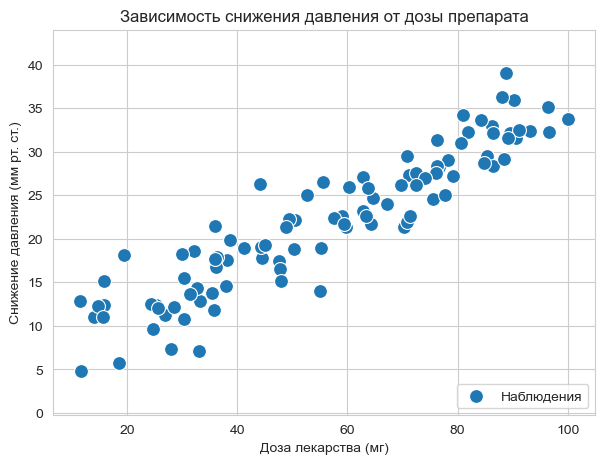

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.set_xlim(df['dose'].min() - 5, df['dose'].max() + 5)
ax.set_ylim(df['delta'].min() - 5, df['delta'].max() + 5)

sns.scatterplot(data=df, x='dose', y='delta', 
                color='C0', s=100, edgecolor='white',
                label='Наблюдения')

ax.set_xlabel('Доза лекарства (мг)')
ax.set_ylabel('Снижение давления (мм рт. ст.)')
ax.set_title('Зависимость снижения давления от дозы препарата')
ax.legend(loc=4)

plt.show()

Теперь — ключевой момент. Мы должны объяснить модели, что от неё требуется.

На языке машинного обучения это звучит так:
— `X` — признаки, то, **на основе чего** мы делаем прогноз (у нас это доза);
— `y` — целевая переменная, то, **что мы хотим предсказать** (у нас это снижение давления).

Это классическая постановка задачи обучения с учителем: «Вот тебе примеры, посмотри на них и найди закономерность».

Мы используем `LinearRegression` из библиотеки `sklearn`. На данный момент это просто чёрный ящик, который умеет проводить прямую через облако точек. Как именно он это делает — разберёмся позже. Пока — верим и пользуемся.

In [4]:
X = df[['dose']]
y = df['delta']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

Модель обучена. Что это значит?

Это значит, что внутри неё теперь живут два числа:
— **коэффициент наклона** (`coef_`) — на сколько в среднем меняется давление при добавлении 1 мг препарата;
— **свободный член** (`intercept_`) — каким было бы снижение давления при нулевой дозе (чисто теоретически).

Если умножить дозу на коэффициент и прибавить свободный член — получится прогноз. Это и есть уравнение прямой:

$$ \text{снижение} = \text{coef} \cdot \text{доза} + \text{intercept} $$

Давайте нарисуем эту прямую поверх облака точек. Модель пыталась провести её так, чтобы в среднем ошибаться как можно меньше. Получилось ли у неё — судите сами.


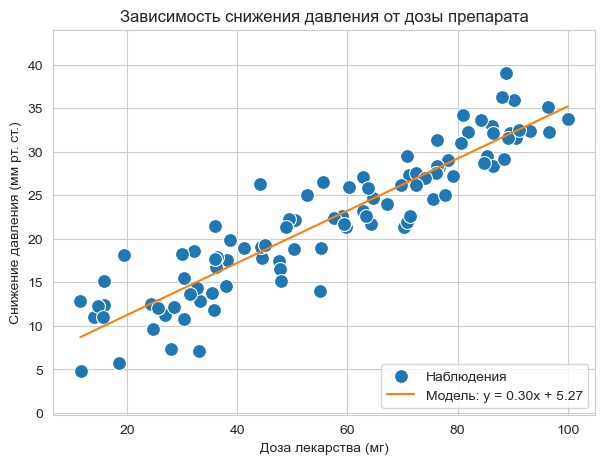

In [5]:
x_range = np.linspace(df['dose'].min(), df['dose'].max(), 100)
y_range = model.predict(x_range.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(7, 5))

ax.set_xlim(df['dose'].min() - 5, df['dose'].max() + 5)
ax.set_ylim(df['delta'].min() - 5, df['delta'].max() + 5)

sns.scatterplot(data=df, x='dose', y='delta', 
                color='C0', s=100, edgecolor='white',
                label='Наблюдения')

ax.plot(x_range, y_range, '-', color='C1',
        label=f'Модель: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

ax.set_xlabel('Доза лекарства (мг)')
ax.set_ylabel('Снижение давления (мм рт. ст.)')
ax.set_title('Зависимость снижения давления от дозы препарата')
ax.legend(loc=4)

plt.show()

Прямая построена. Но мы строили её не ради эстетики. Врач берет модель и спрашивает: «Я хочу назначить 55 мг. Какой будет эффект?» Модель отвечает не задумываясь. Ей не нужно думать — она уже всё посчитала, когда провела прямую. Мы просто передаём новое значение `X` (ту самую дозу 55 мг) и получаем `y` (прогноз снижения давления).

Обратите внимание: мы не говорим модели «пациент номер 101». Мы говорим: «Представь, что доза равна 55. Что ты скажешь?» И модель подставляет 55 в своё уравнение прямой. Это и есть **прогнозирование**. Это не магия. Это алгебра.

In [6]:
new_data = 55
prediction = model.predict([[new_data]])
prediction[0]

21.727717181637356

Добавим на график точку нового прогноза.

Видите? Она легла точно на прямую. Потому что прямая — это и есть модель. Всё, что модель может сказать о мире, она говорит этой прямой. Точка для 55 мг не может оказаться где-то в стороне — она обязана лежать на линии.

Это важный момент. Модель не знает, что на самом деле произойдёт с конкретным пациентом. Она знает только то, что **в среднем** для такой дозы эффект будет таким. Реальность может отклониться — и мы увидим эти отклонения, когда будем говорить об остатках и ошибках. Но это тема для отдельного разговора.

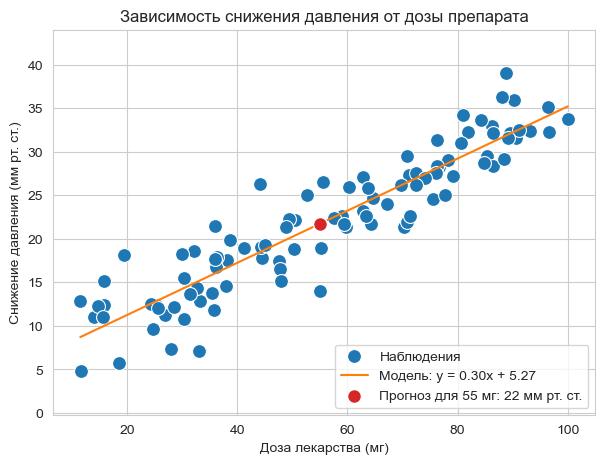

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.set_xlim(df['dose'].min() - 5, df['dose'].max() + 5)
ax.set_ylim(df['delta'].min() - 5, df['delta'].max() + 5)

sns.scatterplot(data=df, x='dose', y='delta', 
                color='C0', s=100, edgecolor='white',
                label='Наблюдения')

ax.plot(x_range, y_range, '-', color='C1',
        label=f'Модель: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

ax.scatter(new_data, prediction[0], color='C3',s=100, 
           zorder=5, edgecolor='white',
           label=f'Прогноз для {new_data} мг: {prediction[0]:.0f} мм рт. ст.')

ax.set_xlabel('Доза лекарства (мг)')
ax.set_ylabel('Снижение давления (мм рт. ст.)')
ax.set_title('Зависимость снижения давления от дозы препарата')
ax.legend(loc=4)

plt.show()

### Резюме

Мы взяли реальную задачу — подбор дозировки лекарства — и за четыре шага превратили её в работающую прогнозирующую модель:

1. Загрузили данные — 100 наблюдений, каждое с известной дозой и известным результатом.
2. Выделили признаки и целевую переменную — `X` (то, что знаем) и `y` (то, что хотим предсказать).
3. Обучили модель — она нашла прямую, которая лучше всего описывает данные.
4. Сделали прогноз — подали на вход новое значение и получили ответ.

Никакой магии. Только линейная алгебра внутри `fit()` и немного здравого смысла снаружи.

В следующих параграфах мы разберём:
— как именно модель ищет эту прямую (спойлер: минимизирует ошибки);
— что такое качество прогноза;
— и почему эта простая схема работает в сотнях реальных задач — от финансов до медицины.

А пока — запомните это чувство. Чувство, когда вы подаёте модели новые данные, а она отвечает вам числом. Это первый шаг из мира «анализируем прошлое» в мир «предсказываем будущее».

## § 2. Прогноз как цвет точки

Вы, наверное, думаете, что прогнозировать можно только числа. Мол, дали дозу — получили цифру снижения давления. Красиво, понятно, по-взрослому. Но жизнь, дорогие мои, устроена сложнее. Иногда нам нужно ответить не «сколько», а «да» или «нет». Или, если угодно, «чёрное» или «белое».

Именно здесь на сцену выходит бинарная классификация. Задача простая до неприличия: у нас есть два класса, и мы хотим относить новые объекты к одному из них. Никаких полутонов, никаких «может быть». Только 0 или 1.

Давайте представим себя владельцами колл-центра. (Я знаю, вы мечтали об этом всю жизнь.) Мы записываем каждый звонок: сколько минут длился разговор и насколько эмоциональным был тон клиента по шкале от 0 до 4. И, самое главное, мы фиксируем — бросили ли трубку до того, как оператор успел попрощаться.

In [8]:
df = pd.read_csv('data/hung_up.csv')
df

,duration,tone,hung_up
0,6.20,1.66,0
1,4.70,2.02,1
2,4.84,1.46,1
3,6.84,3.62,1
4,3.94,2.27,1
...,...,...,...
75,4.22,2.27,1
76,2.58,2.69,1
77,2.58,2.08,1
78,4.63,1.42,1


Звучит знакомо? В этом и заключается проклятие реальных данных: мы всегда хотим знать, кто уйдёт, а кто останется. Взгляните на облако точек. Теперь у нас не синие точки, размазанные вокруг прямой, а две чёткие группы: синие — те, кто дослушал до конца, и оранжевые — те, кто бросил трубку:

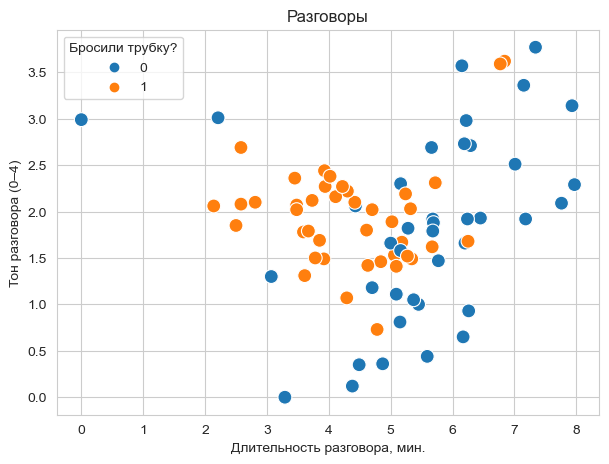

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='duration', y='tone', hue='hung_up', s=100)

ax.set_title('Разговоры')
ax.set_xlabel('Длительность разговора, мин.')
ax.set_ylabel('Тон разговора (0–4)')
ax.legend(title='Бросили трубку?', loc='upper left')

plt.show()

Данные загружены. Можем приступать. Но сразу предупреждаю: инструмент будет другой. Линейная регрессия здесь бессильна — нам нужно не проводить прямую, а резать пространство на куски. И делать мы это будем с помощью kNN — метода k ближайших соседей. kNN работает просто: «Скажи мне, кто твои друзья, и я скажу, кто ты». Если у новой точки пять ближайших соседей из тренировочных данных — и все они, скажем, повесили трубку, — то и наша новая точка, скорее всего, поступит так же. Никакой магии. Только география данных.

Обратите внимание: синтаксис тот же самый. Мы по-прежнему выделяем X и y, по-прежнему вызываем `fit()`. Меняется только название модели и, разумеется, то, что происходит под капотом. Но об этом мы поговорим позже. А сейчас — доверьтесь чёрному ящику.

In [10]:
X = df[['duration', 'tone']]
y = df['hung_up']

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X, y)

KNeighborsClassifier()

Есть обученная модель. 

Теперь представим, что поступил новый звонок. Разговор длился 5.5 минут, тон — 1.2 (спокойный, почти равнодушный). Бросит он трубку или нет? Мы пока не знаем.

In [11]:
new_data = np.array([[5.5, 1.2]])

 Нанесём его на график нейтральным цветом — пусть повисит в неопределённости.

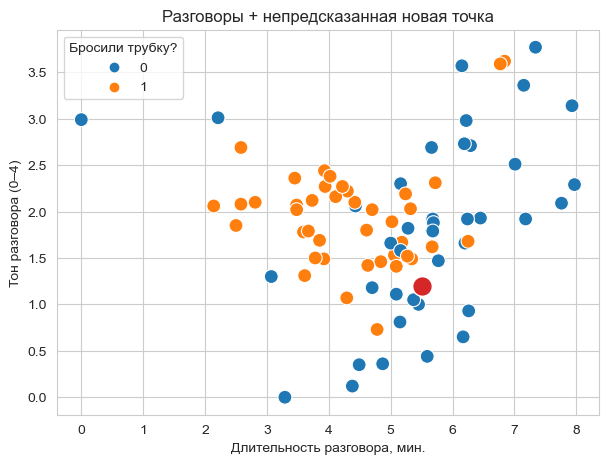

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='duration', y='tone', hue='hung_up', s=100)
ax.scatter(new_data[0, 0], new_data[0, 1], color='C3', s=200, edgecolor='white')

ax.set_title('Разговоры + непредсказанная новая точка')
ax.set_xlabel('Длительность разговора, мин.')
ax.set_ylabel('Тон разговора (0–4)')
ax.legend(title='Бросили трубку?', loc='upper left')

plt.show()

И вот — момент истины. Мы пишем `predict()` и получаем ответ: 0. Не бросил. 

In [13]:
prediction = knn.predict(new_data)[0]
prediction

0

Перекрашиваем точку в синий цвет — цвет лояльных клиентов.

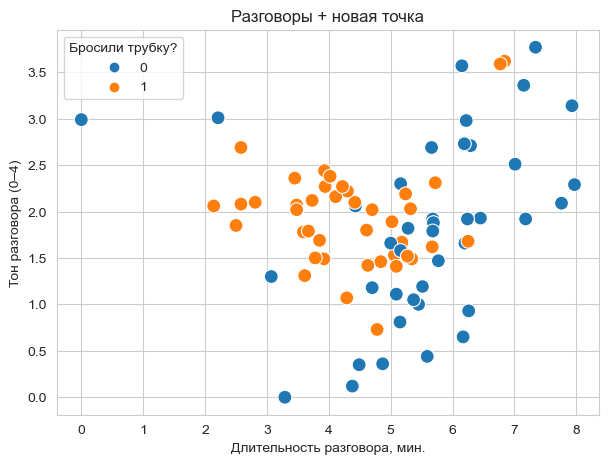

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='duration', y='tone', hue='hung_up', s=100)
ax.scatter(new_data[0, 0], new_data[0, 1], color='C0', s=100, edgecolor='white')

ax.set_title('Разговоры + новая точка')
ax.set_xlabel('Длительность разговора, мин.')
ax.set_ylabel('Тон разговора (0–4)')
ax.legend(title='Бросили трубку?', loc='upper left')

plt.show()

Классификация свершилась. Мы не просто смотрим на облако точек и гадаем — мы построили модель, которая принимает решение.


### Резюме

Мы снова прошли все четыре шага:

- Загрузили данные — 80 звонков с двумя признаками и известным исходом.

- Выделили признаки и целевую переменную — длительность и тон против факта «бросил трубку».

- Обучили модель — kNN запомнил расположение точек и готов к сравнению.

- Сделали прогноз — подали на вход новые координаты и получили ответ.

Разница с регрессией только в типе ответа. Там мы предсказывали число. Здесь — метку класса. Но философия та же: мы берём прошлое, находим в нём закономерность и экстраполируем её на будущее.

## § 3. Основные понятия стохастического прогнозирования

До сих пор мы работали на уровне кухни. Брали данные, подсовывали их модели, получали ответ. Это было весело, познавательно и, главное, наглядно. Но если вы думаете, что машинное обучение — это только «вызвал fit — получил predict», то я вынуждена вас разочаровать. Впереди — самая скучная (и одновременно самая важная) часть: формализация.

Зачем она нужна? А затем, что без неё вы — как хирург, который умеет держать скальпель, но не знает анатомии. Вы сможете повторить операцию по памяти, но если что-то пойдёт не так — вы беспомощны.

В этом параграфе мы разберём прогнозирующую модель по косточкам. Мы ответим на вопросы:

- Что такое модель на самом деле — не метафорически, а формально?

- Как она учится — и почему это называется «обучение», а не «магия»?

- Чем параметры отличаются от гиперпараметров?

- Почему размерность задачи — это не просто скучное число, а ключ к пониманию того, как модель видит мир?

Приготовьтесь. Дальше будет много формул, значков argmin и суровой терминологии. Но я обещаю: если вы это поймёте — вы перестанете быть пользователями библиотек и станете инженерами, которыt понимают, что у них там вертится под капотом.

### 3.1. Что такое модель на самом деле

Давайте сразу расставим точки над Ё. Модель — это не чёрный ящик. Не магия. И не просто «функция из библиотеки, которую вызвал и забыл».

Модель — это формализованное предположение о структуре данных. Или, если угодно, гипотеза. Мы говорим: «Я предполагаю, что между признаками и целевой переменной существует связь. И я знаю, как эта связь устроена — ну, по крайней мере, я могу её записать в виде формулы».

#### 3.1.1. Модель как алгоритм

У каждой модели есть математическая форма. И эта форма определяет, как модель будет превращать входные данные в предсказание.

Для линейной регрессии форма проста и элегантна:

$$
y = w_1x_1 + w_2x_2 + \dots + w_nx_n + w_0
$$

где $y$ — предсказанное значение, $x_i$ — значения предикторов, $w_i$ — веса (`coef_`), а $w_0$ — свободный член (`intercept_`). Всё. Это целая вселенная, упакованная в одну строку. Линейная регрессия — ленивый алгоритм: он просто вычисляет значение по формуле. Никаких циклов, никаких поисков — одно арифметическое действие. Быстро, дёшево и сердито.

Для kNN (k ближайших соседей) алгоритм — уже не формула, а процедура, причём не самая быстрая:

1) Получить на вход точку $x_{\rm new}$, для которой нужно сделать предсказание.

2) Найти $k$ ближайших к ней точек из обучающей выборки (по евклидову расстоянию, но можно и по другой метрике)

3) Провести голосование большинством — какой класс встречается чаще, тот и побеждает.

kNN — жадный алгоритм в том смысле, что он не строит обобщающей модели. Он каждый раз «смотрит по сторонам» и принимает решение на лету. Его знание о мире хранится не в компактных параметрах, а в россыпи точек обучающей выборки. Чем больше точек — тем тяжелее багаж знаний.

Разные подходы — одна суть. Какой бы ни была форма модели, её интерфейс один: модель принимает `X` (признаки) и возвращает `y_pred` (прогноз). Всё остальное — детали реализации. Но именно эти детали определяют, насколько быстро, точно и осмысленно модель будет работать.

#### 3.1.2. Модель как упрощение

А теперь — плохая новость, которую новички обычно пропускают мимо ушей, а зря.

**Модель всегда не права.**

Да-да. Вы не ослышались. Любая модель — это упрощение. Мы не можем описать реальность точь-в-точь. Мы можем только найти наилучшее приближение в рамках выбранной формы.

Линейная регрессия предполагает, что связь между признаками и целью — линейная. А если она нелинейная? Тогда модель будет ошибаться. И это нормально. kNN предполагает, что близкие точки имеют близкие значения целевой переменной. А если данные разрежены? Если шум слишком велик? Тогда kNN начнёт «шуметь» вместе с данными.

В этом нет трагедии. Более того, в этом — смысл машинного обучения. Мы сознательно идём на упрощение, потому что упрощение даёт нам возможность обобщать. Идеально сложная модель, которая помнит каждую точку обучающей выборки, — это просто словарь, а не модель. Она бесполезна на новых данных.

Хорошая модель — это та, которая ошибается ровно настолько, насколько это неизбежно. И ни на йоту больше.

### 3.2. Обучение модели

Давайте сначала на пальцах.

Представьте, что вы — студент, который готовится к экзамену по математике. У вас есть учебник с примерами (это — обучающая выборка). Вы смотрите на пример, пытаетесь решить, смотрите в ответ — ошиблись. Вы запоминаете, в чём была ошибка, и пробуете снова. И так — сотни раз. В какой-то момент вы начинаете решать правильно не потому, что запомнили ответы, а потому, что поняли закономерность.

Вот это и есть обучение.

Модель делает то же самое. У неё есть:

- X — условие задачи (числа, картинки, текст — неважно),

- y — правильный ответ (учитель подсказал).

Какая-то формула, которая пока ничего не умеет. Модель подставляет X в свою формулу, получает предсказание — и сравнивает с правильным y. Если ошиблась — чуть-чуть подкручивает свои внутренние шестерёнки. И так — много раз. До тех пор, пока ошибка не станет достаточно маленькой.

#### 3.2.1. Что значит «обучить» — формально

А теперь — строго. Снимите розовые очки, надевайте очки в черной оправе, потому что бучение модели — это процесс настройки её параметров таким образом, чтобы минимизировать ошибку на обучающей выборке.

Здесь нам понадобится два новых понятия.


#### Функция потерь (Loss Function)

Функция потерь — это числовая метрика, которая показывает, насколько сильно модель ошибается. самая популярная функция потерь для регрессии  — среднеквадратичная ошибка:

$$
L(y_{\rm true}, y_{\rm pred}) = \frac{1}{N}\sum_{i = 1}^N (y_{{\rm true}, i} - y_{{\rm pred}, i})^2\,.
$$

Для задачи классификации в kNN — часто используют долю неверных классификаций:


$$
L(y_{\rm true}, y_{\rm pred}) = \frac{1}{N}\sum_{i = 1}^N {\rm I}(y_{{\rm true}, i} \ne y_{{\rm pred}, i})\,,
$$

где ${\rm I}$ — индикаторная функция: 1, если условие выполняется, и 0 — если нет. Суть одна: чем меньше значение функции потерь — тем лучше модель.


#### Задача оптимизации

Обучение модели — это решение задачи оптимизации. Формально это записывается так:

$$
\Theta^* = {\rm argmin}_\Theta L(y_{\rm true}, {\rm Alg}(X, \Theta)).
$$

Здесь:

- $\Theta$ — параметры модели,

- ${\rm Alg}(X, \Theta)$  — модель, которая принимает признаки $X$ и текущие параметры $\Theta$ и возвращает предсказание,

- ${\rm argmin}_\Theta$ — такие значения параметров $\Theta$, при которых функция потерь минимальна,

- $\Theta^*$ — оптимальные параметры.

Вот это — и есть машинное обучение. Не магия и не шаманство. А решение задачи оптимизации.

Как именно алгоритм ищет эти оптимальные параметры — зависит от модели. Линейная регрессия может использовать метод наименьших квадратов или метод ортогональных проекций. Для kNN, как мы уже знаем, «обучение» сводится к запоминанию данных — поэтому argmin там не применяется, но формально мы всё равно говорим, что «модель обучена», когда она запомнила выборку.

#### 3.2.2. Обучение с учителем и без учителя

Мы с вами сейчас говорим об очень конкретном типе машинного обучения — обучении с учителем (supervised learning).

Название говорит само за себя. У нас есть «учитель» — это правильные ответы $y_{\rm true}$, которыми мы располагаем. Другими словами, у нас размеченные данные: для каждого объекта из обучающей выборки мы знаем, каков правильный ответ.

Это похоже на то, как родитель учит ребёнка называть животных. Родитель показывает картинку кота и спрашивает: «Это кто?» Ребёнок говорит: «Собака». Но родитель знает **правильный ответ**. Родитель поправляет: «Нет, это кот». Ребёнок запоминает. В следующий раз — с большей вероятностью ребенок ответит правильно. В нашем случае родитель — это обучающая выборка с правильными ответами. Ребёнок — модель. И процесс длится до тех пор, пока количество ошибок не станет приемлемым.


- **Регрессия:** учитель говорит «правильный ответ — число 10.5, а ты предсказал 8.2. Ошибка — 2.3». И модель старается уменьшить ошибку.

- **Классификация:** учитель говорит «правильный класс — 0, а ты предсказал 1. Ты ошибся». Модель запоминает и старается не ошибаться в похожих случаях.

Существует и другой мир — обучение без учителя. Там у нас нет правильных ответов, и модель должна сама найти в данных какую-то структуру (например — в задаче  кластеризации). Это — совсем другая история, и мы будем говорить о ней в третьем модуле. 

А пока мы твёрдо стоим на позициях обучения с учителем. У нас есть ответы. Мы знаем, к чему стремиться, и мы используем это знание.

### 3.3. Параметры модели

До сих пор мы говорили о модели как о чём-то абстрактном: «модель обучается», «модель подстраивается». Но что именно она подстраивает? Что у неё внутри? Сейчас мы и вскроем чёрный ящик — не до винтика, но до уровня «понятно, чем шестерёнки смазаны».

Внутри любой обученной модели живут параметры. Это те числа, которые модель «выучила» в процессе fit(). Их можно посмотреть, потрогать и, если нужно, заплакать над ними.

Но сразу предупреждаю: не путайте параметры с настройками. Параметры — это результат обучения, а не то, что вы выбираете заранее. Разница между ними — как между скелетом человека и одеждой, которую вы на него надели. Скелет — это параметры. Одежда — это… Впрочем, не буду забегать вперёд. С одеждой — в следующем разделе. А сейчас — скелет.


#### 3.3.1. Что такое параметры модели

Каждая модель подбирает свои параметры. Это её внутреннее знание о мире, записанное на языке чисел. Посмотрим на двух наших героев. Линейная регрессия. У неё всё прозрачно. Формула модели — это уравнение прямой (или гиперплоскости, если признаков много):

$$
y = w_1x_1 + w_2x_2 + \dots + w_nx_n + w_0
$$


Здесь $w_i$ — это веса (или, на языке sklearn, `model.coef_`). Они показывают, насколько сильно каждый признак 
 влияет на прогноз. Если вес положительный — с ростом признака прогноз растёт. Если отрицательный — падает. Чем больше вес по модулю — тем важнее признак. А $w_0$ — это свободный член (`model.intercept_`), то есть — прогноз при нулевых значениях всех признаков, чисто формальная конструкция, но без неё прямая не сможет оторваться от нуля. Важный момент: в линейной регрессии параметров ровно столько, сколько признаков, плюс один (свободный член). Никаких лишних. Просто и элегантно.


А вот с ближайшими соседями — сюрприз: у kNN  вообще нет параметров в классическом смысле. То есть нет никаких чисел, которые настраиваются. Потому что kNN во время `fit()` ничего не подбирает. Что же он делает? Он запоминает обучающую выборку. Все точки: их координаты и их метки. Формально это выглядит так: атрибут `knn._fit_X` хранит массив признаков, а `knn._y` — массив ответов. И всё. Никаких весов, никаких коэффициентов. kNN — это ленивый студент, который не учит билеты, а просто носит с собой учебник и листает его на экзамене.


Это важный контраст. Одна модель учит параметры. Другая — просто помнит точки. И обе при этом считаются «обученными».


#### 3.3.2. Как параметры выглядят в коде

Хорошо, с теорией разобрались. Теперь — руки в код. Для линейной регрессии:

In [15]:
model.coef_

array([0.29923184])

Обратите внимание: вернулся массив, хотя это одно число. А почему? — правильно: потому что вообще говоря предикторов может быть больше (и чаще всего именно так и бывает).

А вот свободный член:

In [16]:
model.intercept_ 

5.269965917026738

Это действительно одно число. Всегда. Сколько бы предикторов модели мы не использовали.

In [17]:
knn._fit_X 

array([[6.2 , 1.66],
       [4.7 , 2.02],
       [4.84, 1.46],
       [6.84, 3.62],
       [3.94, 2.27],
       [2.14, 2.06],
       [3.59, 1.78],
       [5.16, 2.3 ],
       [4.7 , 1.18],
       [3.48, 2.07],
       [4.49, 0.35],
       [3.45, 2.36],
       [4.38, 0.12],
       [5.59, 0.44],
       [5.34, 1.49],
       [5.32, 2.03],
       [5.68, 1.92],
       [2.5 , 1.85],
       [4.78, 0.73],
       [5.24, 2.19],
       [5.18, 1.67],
       [6.26, 0.93],
       [5.67, 1.62],
       [3.92, 1.49],
       [5.02, 1.89],
       [5.09, 1.11],
       [4.29, 1.07],
       [7.34, 3.77],
       [4.43, 2.06],
       [3.93, 2.44],
       [5.06, 1.53],
       [5.15, 0.81],
       [6.29, 2.71],
       [5.69, 1.88],
       [3.85, 1.69],
       [4.02, 2.38],
       [2.21, 3.01],
       [4.42, 2.1 ],
       [5.68, 1.79],
       [7.15, 3.36],
       [6.17, 0.65],
       [3.07, 1.3 ],
       [5.45, 1.  ],
       [6.45, 1.93],
       [4.3 , 2.22],
       [7.76, 2.09],
       [6.77, 3.59],
       [6.19,

In [18]:
knn._y

array([0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1])

Обратите внимание: методы с подчёркиванием (`_fit_X` и `_y`) — это соглашение sklearn, которое говорит: «Я есть, но ты ко мне руками лучше не лезь, если не знаешь, что делаешь». Это не публичный интерфейс. Но если очень хочется подсмотреть — то можно. Не возбраняется.

#### 3.3.3. Почему параметры — это не настройки, а результат

Золотое правило, которое нужно выучить и запомнить на всю оставшуюся жизнь: параметры модели — это не то, что выбирает человек. Человек не говорит: «Сделай наклон 0.7». Человек говорит: «Найди лучший наклон». И алгоритм во время fit() находит его. Параметры — это результат решения задачи оптимизации, которую мы разбирали в предыдущем разделе. Помните 
$\Theta^* = {\rm argmin}_\Theta L(y_{\rm true}, {\rm Alg}(X, \Theta))$? Вот $\Theta^*$ — это и есть подобранные параметры. Их нашёл алгоритм, и теперь они принадлежат модели.

Вы можете посмотреть на них, можете проанализировать, можете даже округлить их для отчёта. Но вы не можете изменять. Ну...  то есть можете — присвоить новое значение напрямую, но тогда это будете уже не обученная модель, а модель, которую вы научили врать. Если вы вручную выставите `model.coef_` — вы сломаете всё, чему модель научилась. Не делайте так.

### 3.4. Гиперпараметры модели

Мы выяснили, что параметры — это «святая святых», которые модель добывает сама, копаясь в данных. Но у каждой модели есть настройки верхнего уровня, которые определяют, как именно она будет учиться. 

Добро пожаловать в мир гиперпараметров.


#### 3.4.1. Что такое гиперпараметры модели

Гиперпараметр — это рычаг, который вы крутите до того, как нажали кнопку fit(). Это конфигурация алгоритма. Модель в процессе обучения может изменить свои веса, но она никогда, ни при каких обстоятельствах не изменит n_neighbors в kNN. Гиперпараметры — это прерогатива человека. Это тот самый момент, где вы берете на себя ответственность за судьбу модели. Алгоритм может быть гениальным, но если вы задали неверные гиперпараметры, он будет «гениально» ошибаться.

#### 3.4.2. Примеры гиперпараметров

Давайте на конкретике, чтобы без лишних слов:

- kNN: Его главный гиперпараметр — n_neighbors (количество соседей). Если вы поставите k=1, модель будет слишком чутко реагировать на шум (переобучение). Если поставите k=N (всё обучающее множество), модель станет максимально усредненной и перестанет замечать локальную структуру данных (недообучение). Выбор k — это ваш личный выбор.

- Линейная регрессия: А вот тут — сюрприз! Простейшая линейная регрессия в базовой реализации не имеет гиперпараметров. Ей не нужно ничего подсказывать. Она просто берет данные и считает минимум ошибки так, как диктует математика. 

- Сложные модели: Чем мощнее оружие, тем больше у него настроек. Здесь количество гиперпараметров может исчисляться десятками.

Количество гиперпараметров — это прямой показатель того, сколько «решений» должен принять человек, прежде чем машина начнет считать.


#### 3.4.3. Почему гиперпараметры — это боль

Если бы я мог передать вам всю горечь этого процесса через текст, вы бы ощутили её кожей. Почему это горько и больно? —потому что гиперпараметры нельзя выучить из данных. Вы не можете написать `knn.fit(X, y)` и ждать, что она сама подберет идеальный `n_neighbors`. Если алгоритм сам подбирает свои внутренние параметры, то гиперпараметры нам приходится подбирать снаружи. Это превращает процесс обучения в итеративный цикл:

1) Выбрали значения гиперпараметров.

2) Запустили обучение.

3) Померили качество на отложенной выборке.

4) Прокляли всё, в особенности — два дня: день, когда вы родились, и день, когда решили стать датасайентистом.

5) Изменили гиперпараметры.

6) Повторили.


Это называется — «оптимизация гиперпараметров». Своеобразное искусство, граничащее с нудным перебором вариантов. Но именно здесь рождается разница между просто моделью и моделью, которая работает.

### 3.5. Предикторы и таргеты

Давайте формализуем то, с чем мы работаем каждый день. Любая задача обучения с учителем — это игра в «вопрос-ответ». 

**Предикторы (Features/ X).** Это наш «вопрос». Это данные, на основании которых мы пытаемся что-то понять. В табличных данных это столбики с характеристиками. Математически это матрица X, где строки — это объекты, а столбцы — признаки.

**Таргет (Target/ y).** Это наш «ответ». То, что мы хотим предсказать. Это может быть число (для регрессии) или метка класса (для классификации). Математически это вектор y (или столбец-матрица).

Почему это важно? Потому что весь Machine Learning — это попытка выстроить жесткую математическую связь: 

$$
{\rm Alg}: X\longrightarrow y\,. 
$$

Мы ищем алгоритм ${\rm Alg}$, который превращает шумные «вопросы» X в максимально точные «ответы» y. Если признаки подобраны плохо — модель будет выдавать гадание на кофейной гуще. Если таргет выбран неверно или «зашумлен» — модель выучит не ту закономерность.


### 3.6. Размерности: почему всё так сложно?

А теперь — «почему это всё не работает, если я подаю для прогноза одно число?». Студенты обожают этот вопрос. 

Посмотрите на сигнатуру метода `predict()`. Почему она требует массив (матрицу), а не одиночное число? 

Ответ прост, как мир: модель всегда ждет пакет данных. Даже если вы хотите сделать прогноз для одного единственного объекта, библиотека scikit-learn требует, чтобы вы обернули его в структуру: на вход подвется двумерный массив (1, n_features), а это матрица с одной строкой, и тогда на входе получается двумерный массив (1, n_tergets), и это тоже матрица с одной строкой. И даже если у вас всего один признак и один таргет, то это будет матрица (1, 1). 

Зачем эта бюрократия? — xтобы не плодить сущности. Алгоритм не должен каждый раз спрашивать: «Ты мне прислал один объект или сто?». Он раз и навсегда настроен на перемножение матриц. А матрица — это всегда 2D. 

Если вы подадите, например, [1.5] вместо [[1.5]], Python выдаст вам ошибку, в которой будет что-то вроде: «Ожидалась 2D-матрица, а ты прислал 1D-вектор». В этот момент вы должны вспомнить этот параграф и не паниковать, а просто «довернуть» размерность. 

## § 4. Многомерное прогнозирование

Представьте, что мы наконец-то перестали быть теоретиками. У нас в руках реальная задача, реальный бизнес, живые деньги — и никакой возможности сказать «ой, а я думал, это просто лаба». Сеть отелей «Уютный Номер» прислала нам данные и попросила: «Ребята, помогите нам назначать цену за номер так, чтобы мы не разорились и не отпугнули гостей». Кейс идеально ложится на линейную регрессию: много факторов честно влияют на цену, и наша задача — это влияние поймать. Никакой магии, только линейная алгебра в красивой обёртке scikit-learn.

### 4.1. Линейная регрессия. Несколько предикторов — один таргет

Взгляните на датасет. 

Каждая строка здесь — это конкретное бронирование: кто-то когда-то выбрал отель, заехал, оставил отзыв и заплатил. У нас есть куча так называемых **предикторов** — от сезона и дня недели до расстояния до центра города, — и ровно один **таргет**: цена за ночь. То есть каждому набору признаков соответствует реальное число рублей, и мы собираемся спросить у модели: «Слушай, вот, что было у нас в прошлом. А если появится новый заказ, — какую цену ты назовёшь?» На самом деле, за нас умными людми уже написан `LinearRegression`, который внутри честно перемножает матрицу признаков на вектор коэффициентов и прибавляет `intercept`. 

Наша работа — дать ему данные и ничего не перепутать.

In [19]:
df = pd.read_csv('data/hotel.csv')
df

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days,price
0,3,2,1,8,3,4.58,0,73,-1,3369.41
1,4,6,2,19,4,11.75,0,26,-1,3685.47
2,1,2,5,19,4,11.71,0,162,-1,2552.05
3,3,5,4,17,3,7.52,0,61,-1,3417.73
4,3,3,2,18,4,1.72,1,262,-1,4954.84
...,...,...,...,...,...,...,...,...,...,...
8995,4,3,1,1,5,6.10,0,258,-1,5244.75
8996,1,1,2,2,4,10.43,1,175,-1,2443.73
8997,2,2,4,11,3,6.02,1,145,-1,1771.46
8998,1,0,5,12,4,2.71,1,130,-1,3064.14


#### Контекст
Сеть отелей «Уютный Номер» хочет оптимизировать динамическое ценообразование и управление загрузкой номеров в зависимости от множества факторов. У них есть исторические данные по каждому бронированию.

#### Предикторы

- season — сезон (1 — зима, 2 — весна, 3 — лето, 4 — осень) (int),

- weekday — день недели (0 — понедельник, … 6 — воскресенье) (int),

- guests — количество гостей (1–6) (int),

- nights — длительность проживания (1–21 ночей) (int),

- stars — звёздность отеля (3–5) (int),

- dist_center — расстояние до центра города (0.3–15.0 км)	(float),

- breakfast — наличие завтрака (0 — нет, 1 — да) (int),

- early_book — раннее бронирование (0–365 дней до заезда) (int)

- cancel_days — отмена бронирования (–1 — не отменено, 0–30 дней до заезда) (int)


#### Таргет

- price — цена за ночь (руб) (float)

#### Бизнес-задача

Прогнозировать `price` — чтобы рекомендовать оптимальную стоимость номера в реальном времени, максимизируя выручку.

Первым делом разбиваем наш DataFrame на две части: всё, что не `price`, отправляем в `X`, а сам `price` — в `y`. Это классический ритуал, который вы потом будете повторять с закрытыми глазами. Затем создаём модель, обучаем её — и всё, магия случилась. Обратите внимание: `LinearRegression` не сказал нам, что признаков слишком много, что какие-то из них бесполезны или что ему не нравится форма данных. Он молча прожевал все столбцы, подобрал коэффициенты и теперь готов делать прогнозы.

In [20]:
X = df.drop(columns=['price'])
y = df['price']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

Модель обучена. Дальше что? А дальше — в отель приходит новый гость. Он ещё не заплатил, но мы знаем про него всё: одинокий путешественник, зима, три звезды, завтрак включён, бронировал почти год назад, до центра ехать восемь с половиной километров. Мы заносим эти данные в маленький csv-файлик и смотрим на него — это одна строка. И вот здесь-то и начинается самое весёлое: как подать одну строку туда, где ждали много строк?

In [21]:
X_new_one = pd.read_csv('data/hotel_new_one.csv')
X_new_one

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days
0,1,3,2,1,3,8.49,1,356,17


Мы вызываем `model.predict()` — и что получаем? Список. Массив с одним числом. Модель не стала подыгрывать и говорить «вот твоё единственное число», она по-прежнему вернула одномерный контейнер. Почему — мы разбирали в разделе 3.6, и я очень надеюсь, что сейчас вы мысленно ударили себя по лбу и сказали: «Ах да, размерности!». Вы подали матрицу размером (1, 9), и модель честно вернула матрицу ответов размером (1, 1). То самое «одно число в списке» и есть [2639.13...]. Первое время будет казаться, что это неудобно, потом привыкнете, а потом будете находить баги с пол-оборота, просто глядя на форму вывода.

In [22]:
y_pred = model.predict(X_new_one)
y_pred[0]

2639.130907719403

Сеть отелей — это не одно бронирование в неделю. Скорее всего, вам пришлют сразу пачку новых запросов на разные даты, разные отели и разных гостей. И вот тут наступает момент истины: модели действительно всё равно. Вы загружаете `hotel_new_many.csv` — тысячу строк, но те же девять столбцов.

In [23]:
X_new_many = pd.read_csv('data/hotel_new_many.csv')
X_new_many

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days
0,1,3,2,1,3,8.49,1,356,17
1,4,4,1,13,4,0.90,0,132,-1
2,1,1,5,13,4,9.92,0,8,-1
3,2,6,2,2,3,11.22,0,203,-1
4,1,6,3,10,4,12.94,0,15,-1
...,...,...,...,...,...,...,...,...,...
995,4,6,3,19,4,3.57,0,159,6
996,3,6,3,2,3,3.40,1,103,-1
997,2,1,4,12,3,5.00,0,350,-1
998,2,5,4,8,4,2.28,0,175,26


А теперь вызываете ровно ту же строчку кода, что и для одного объекта. Никаких for-циклов, никаких «а давайте вызовем `predict` тысячу раз». Нет. Просто даёте матрицу (1000, 9), и модель отдаёт ответы для каждой строки. Единственная разница — теперь вы видите нормальный, длинный список чисел, и это именно то, чего вы интуитивно ждали. Такое поведение очень удобно: не нужно переключаться между режимами «одно наблюдение» и «много наблюдений», модель всегда работает с пакетом. А значит, вы можете спроектировать систему, которая принимает любое количество запросов и не ломается на граничном случае, когда запрос всего один.

Для демонстрации печатаем первые десять предсказанных цен. От трёх с небольшим тысяч до пяти с лишним — вменяемые цифры для трёх- и четырёхзвёздочных отелей, правда же? Модель не сломалась, не ушла в минус и не выдала миллион рублей за ночь в отеле без завтрака на отшибе. Это значит, что линейная регрессия справилась с тысячей записей точно так же, как справлялась с одним. 

In [24]:
y_pred = model.predict(X_new_many)
y_pred[:10]

array([2639.13090772, 4466.51697603, 2597.28090085, 2533.71946744,
       3129.94277538, 5261.95206845, 4473.04718105, 4011.61388167,
       2536.39151383, 4225.76194569])

А мы двигаемся дальше: сейчас научим модель предсказывать не один таргет, а сразу несколько.

### 4.2. Линейная регрессия. Несколько предикторов — несколько таргетов

Отлично, с ценой разобрались. 

Но я слышу, как самый въедливый студент на задней парте уже тянет руку: «Профессор, а если мне нужно предсказать не только цену, но и, скажем, вероятность того, что гость откажется от бронирования? Или оценку, которую он поставит отелю?» И вот тут — минута триумфа линейной регрессии. Ей вообще всё равно, сколько таргетов вы навесите, — лишь бы вы дали ей исторические данные по каждому из них. 

Смотрите: у нас есть отдельный файлик hotel_extra.csv, в котором для тех же девяти тысяч бронирований записаны cancel_prob и rating. Те самые «ещё два ответа», которые мы хотим предсказывать. Пока это просто два столбца, которые мы сейчас объединим с нашим основным датафреймом.

In [25]:
extra = pd.read_csv('data/hotel_extra.csv')
extra

,cancel_prob,rating
0,0.099,2
1,0.156,3
2,0.063,2
3,0.139,3
4,0.263,4
...,...,...
8995,0.289,4
8996,0.307,4
8997,0.262,4
8998,0.106,4


Конкатенируем — используем старый добрый `pd.concat`. Вы же помните из первого модуля: `axis=1` означает «приклеиваем не новые строки, а новые столбцы». Правая часть приезжает к правой, и `df` внезапно разбухает до двенадцати колонок. Теперь у нас есть всё: девять предикторов и три таргета — `'price'`, `'cancel_prob'`, `'rating'`. 

In [26]:
df_extra = pd.concat([df, extra], axis=1)
df_extra

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days,price,cancel_prob,rating
0,3,2,1,8,3,4.58,0,73,-1,3369.41,0.099,2
1,4,6,2,19,4,11.75,0,26,-1,3685.47,0.156,3
2,1,2,5,19,4,11.71,0,162,-1,2552.05,0.063,2
3,3,5,4,17,3,7.52,0,61,-1,3417.73,0.139,3
4,3,3,2,18,4,1.72,1,262,-1,4954.84,0.263,4
...,...,...,...,...,...,...,...,...,...,...,...,...
8995,4,3,1,1,5,6.10,0,258,-1,5244.75,0.289,4
8996,1,1,2,2,4,10.43,1,175,-1,2443.73,0.307,4
8997,2,2,4,11,3,6.02,1,145,-1,1771.46,0.262,4
8998,1,0,5,12,4,2.71,1,130,-1,3064.14,0.106,4


Дальше — дело техники. Определяем `X` как всё, что не таргеты, `y` — как три колонки сразу. Модель обучена. 

Обратите внимание: мы использовали тот же класс `LinearRegression`, не меняя вообще ничего. Ни флагов, ни дополнительных параметров. Просто скормили ей более широкую `y`, и модель внутри построила три независимых регрессии параллельно.

In [27]:
X = df_extra.drop(columns=['price', 'cancel_prob', 'rating'])
y = df_extra[['price', 'cancel_prob', 'rating']]

model = LinearRegression()
model.fit(X, y)

LinearRegression()

Теперь — прогноз для одного бронирования. Мы снова берём наш объект `X_new_one` (гость номер один, зима, три звезды, завтрак включён) и вызываем `predict()`. И получаем… что-то похожее на матрицу. Три числа, которые мы ожидали, но нои обёрнуты в дважды вложенный массив. В прошлом разделе для одного таргета модель возвращала одномерный список из одного числа, и мы уже смирились. Теперь таргетов три, поэтому на выходе — двумерный массив размером (1, 3). Одна строка, три колонки. Внешние скобки говорят: «Вот пакет ответов». Внутренние скобки говорят: «В пакете ровно один объект, и у него три ответа». Это та же история с размерностями, просто мы поднялись на ступеньку выше.

In [28]:
y_pred = model.predict(X_new_one)
y_pred

array([[2.63913091e+03, 5.10645502e-01, 2.32465921e+00]])

Ну а если подать сразу тысячу бронирований, модель и глазом не поведёт. Мы берем `X_new_many` — он у нас по-прежнему содержит только предикторы, целевые переменные для новых заказов никто не знает, — и вызываем тот же `predict()`. На этот раз на выходе матрица размером (1000, 3): для каждого из тысячи объектов — три предсказанных показателя. Именно поэтому для одного объекта мы и получили двойную вложенность: модель всегда возвращает двумерный массив, просто в случае одного наблюдения в пакете первая размерность вырождается до единицы.

In [29]:
y_pred = model.predict(X_new_many)
y_pred

array([[2.63913091e+03, 5.10645502e-01, 2.32465921e+00],
       [4.46651698e+03, 2.07906607e-01, 3.42728833e+00],
       [2.59728090e+03, 1.70275279e-01, 3.17432324e+00],
       ...,
       [2.35652373e+03, 3.28367800e-01, 2.30908788e+00],
       [3.98270214e+03, 5.62650914e-01, 2.77972245e+00],
       [2.53113320e+03, 1.63597209e-01, 3.11497138e+00]])

Привыкайте: когда вы работаете с многомерным прогнозированием, predict() всегда отдаёт матрицу, какой бы длины ни был вход. Это страшно удобно, когда вы начинаете автоматизировать расчёты и гонять через модель целые файлы.

### 4.3. Бинарная классификация. Несколько предикторов — один таргет

Ну что, друзья мои, давайте познакомимся с нашим новым кейсом. Платформа доставки еды «Быстрый Лось» — название дурацкое, но данные у них хорошие — хочет управлять рисками и не бесить клиентов. Сейчас мы смотрим на историю из девяти тысяч заказов. Девять признаков: время доставки, расстояние до ресторана, температура блюда, рейтинг ресторана, число позиций, сумма, погода, промокод и час заказа. В правом хвосте датафрейма нас скромно ждёт таргет `'late'` — был ли заказ доставлен позже обещанного. Ноль означает «успели», единица — «облажались». Именно его мы и будем учиться предсказывать. Пока — только его.

In [30]:
df = pd.read_csv('data/delivery.csv')
df

,delivery_min,rest_dist,food_temp,rest_rating,items,order_sum,weather,promo,hour,late
0,112,5.17,69,1.64,3,2161.75,0,0,8,0
1,61,12.67,6,3.76,11,4414.00,0,1,14,0
2,102,9.74,13,3.38,11,4014.51,0,0,11,0
3,24,17.58,10,3.99,6,1082.87,0,0,17,0
4,116,5.79,11,1.60,14,4694.44,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
8995,77,5.86,0,1.73,10,259.40,0,1,12,1
8996,62,13.71,68,3.50,2,1741.02,0,0,12,0
8997,42,1.25,8,4.88,5,5468.36,1,0,14,1
8998,80,11.58,13,3.09,12,2451.42,0,0,10,0


#### Контекст

Платформа доставки еды «Быстрый Лось» (FastMoose) хочет автоматизировать контроль качества заказов. Каждый заказ сопровождается большим количеством данных.


#### Датасет

- delivery_min — время доставки (10–120 минут) (int),

- rest_dist — расстояние до ресторана (0.5–20.0 км) (float),

- food_temp — температура блюда при отправке (0–90 °C) (int),

- rest_rating — рейтинг ресторана (1–5) (float),

- items — количество позиций в заказе (1–15) (int),

- order_sum — сумма заказа (200–6000 руб)	(float),

- weather — погода при доставке (0 — ясно, 1 — дождь, 2 — снег) (int),

- promo — наличие промокода (0 — нет, 1 — да) (int),

- hour — время суток (0–23) (int).


#### Таргеты

late — опоздание (0 — вовремя, 1 — опоздание) (int).

#### Бизнес-задача

Нужно уметь прогнозировать опоздание late (0/1) — превышено ли обещанное время доставки. Это позволит компании заранее предупреждать клиентов и назначать компенсацию, снижая негативные отзывы.

Строим модель. Не пугаемся: сейчас это не линейная регрессия, а метод ближайших соседей. Но синтаксис донельзя родной. Точно так же создаём матрицу признаков, убрав из датафрейма колонку `'late'`, и отдельно — вектор y из одного этого столбца. Дальше вызываем `KNeighborsClassifier`, скармливаем ему в метод `fit()` те же `X` и `y`, и модель запоминает всех наших «лосей» вместе с их опозданиями. Никакой магии. Если вы поняли `LinearRegression`, вы уже поняли и `KNeighborsClassifier`. Разные модели — одинаковый интерфейс. Привыкайте к этому.

In [31]:
X = df.drop(columns=['late'])
y = df['late']

knn = KNeighborsClassifier()
knn.fit(X, y)

KNeighborsClassifier()

Модель готова. Теперь к нам приходит новый заказ — один-единственный. Десять позиций, сумма средняя, доставка аж 114 минут, расстояние под двадцать километров. Мы смотрим на него и ещё ничего не знаем: привезут вовремя или нет? Все девять признаков у нас на руках, а таргета, разумеется, нет — иначе зачем бы мы всё это затевали. Мы аккуратно упаковываем эту строку в датафрейм `X_new_one`. Заметьте: здесь ровно те же колонки, что и в обучающей выборке, и ровно в том же порядке. Порядок нарушать нельзя.

In [32]:
X_new_one = pd.read_csv('data/delivery_new_one.csv')
X_new_one

,delivery_min,rest_dist,food_temp,rest_rating,items,order_sum,weather,promo,hour
0,114,19.57,8,2.28,10,1012.07,0,1,7


Вызываем `predict()` и получаем вердикт: [0]. Наша модель, обученная на девяти тысячах примеров, считает, что опоздания не будет. Не «гарантирует», а «считает» — я настаиваю на этой оговорке. Это прогноз, а не пророчество. Но уже на этом этапе «Быстрый Лось» может вести себя по-разному: для предсказанных нулей — стандартный трекинг, для предсказанных единиц — превентивная эсэмэска с извинениями и промокодом. Бизнес-ценность рождается именно здесь, на стыке цифры и решения.

In [33]:
y_pred = knn.predict(X_new_one)
y_pred

array([0], dtype=int64)

Одиночный прогноз — это разминка. В реальности к нам прилетают не отдельные строчки, а целые файлы. Тысяча новых заказов, например. Мы загружаем `delivery_new_many.csv`, в котором те же девять колонок и тысяча строк. 

In [34]:
X_new_many = pd.read_csv('data/delivery_new_many.csv')
X_new_many

,delivery_min,rest_dist,food_temp,rest_rating,items,order_sum,weather,promo,hour
0,114,19.57,8,2.28,10,1012.07,0,1,7
1,81,10.40,35,4.29,12,4134.56,2,0,8
2,110,11.27,83,2.41,2,624.33,1,0,4
3,60,14.39,78,3.89,1,4360.49,1,0,1
4,83,9.95,2,4.11,10,2078.07,0,1,9
...,...,...,...,...,...,...,...,...,...
995,83,14.04,28,2.14,15,1306.52,0,1,18
996,52,7.30,48,1.55,7,610.16,1,0,19
997,90,17.74,74,1.62,10,250.12,1,0,19
998,78,13.50,50,4.88,1,1448.20,1,1,12


И снова вызываем `predict()`. Модель ни на секунду не задумывается — она мгновенно проходит по всем тысяче объектов и выплёвывает тысячу прогнозов. Я вывожу первые сто, чтобы не захламлять экран. Видите эту последовательность нулей и единиц? Это не абстракция. Это конкретные решения для конкретных заказов. Сто строк — сто прогнозов.

In [35]:
y_pred = knn.predict(X_new_many)
y_pred[:100]

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

### 4.2. Бинарная классификация. Несколько предикторов — несколько таргетов

Но «Быстрый Лось» на этом не останавливается. Им мало знать, опоздает курьер или нет. Им хочется понимать: а будет ли негативный отзыв? А вернётся ли клиент через месяц? Это два дополнительных таргета. И у нас, разумеется, есть исторические данные по ним для тех же девяти тысяч заказов. В файле `delivery_extra.csv` лежат два столбца: `bad_review` — ноль или единица, и `reorder` — тоже ноль или единица. Пока что они живут отдельно от основного датафрейма.

In [36]:
extra = pd.read_csv('data/delivery_extra.csv')
extra

,bad_review,reorder
0,1,0
1,0,0
2,0,1
3,1,0
4,1,1
...,...,...
8995,1,0
8996,0,0
8997,1,1
8998,0,0


Берём старый добрый `pd.concat` и клеим наши дополнительные таргеты справа к основному датафрейму. `axis=1` — не забываем. Получаем двенадцать колонок: всё те же девять признаков, плюс старый таргет `late`, плюс два новых — `bad_review` и `reorder`. Теперь у нас в руках полноценный мультитаргетный набор данных. Взгляните на последние три столбца: это три вопроса, на которые мы хотим отвечать одновременно. И модель, как мы сейчас увидим, научится отвечать на них одновременно.

In [37]:
df_extra = pd.concat([df, extra], axis=1)
df_extra

,delivery_min,rest_dist,food_temp,rest_rating,items,order_sum,weather,promo,hour,late,bad_review,reorder
0,112,5.17,69,1.64,3,2161.75,0,0,8,0,1,0
1,61,12.67,6,3.76,11,4414.00,0,1,14,0,0,0
2,102,9.74,13,3.38,11,4014.51,0,0,11,0,0,1
3,24,17.58,10,3.99,6,1082.87,0,0,17,0,1,0
4,116,5.79,11,1.60,14,4694.44,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
8995,77,5.86,0,1.73,10,259.40,0,1,12,1,1,0
8996,62,13.71,68,3.50,2,1741.02,0,0,12,0,0,0
8997,42,1.25,8,4.88,5,5468.36,1,0,14,1,1,1
8998,80,11.58,13,3.09,12,2451.42,0,0,10,0,0,0


Строим модель. 

Честное слово, вы сейчас не увидите ничего нового. Мы снова определяем `X` — всё, кроме трёх таргетных колонок, и `y` — теперь уже не один столбец, а список из трёх. Тот же `KNeighborsClassifier`, тот же `fit()`. Никаких дополнительных параметров, никакого отдельного обучения под каждый таргет. Модель внутри себя строит всё, что нужно, для каждого из трёх бинарных ответов. И делает это за одно и то же время. 

Программистски говоря — полиморфизм. Человечески говоря — красота.

In [38]:
X = df_extra.drop(columns=['late', 'bad_review', 'reorder'])
y = df_extra[['late', 'bad_review', 'reorder']]

knn = KNeighborsClassifier()
knn.fit(X, y)

KNeighborsClassifier()

Теперь — предсказание для одного заказа. Тот же самый `X_new_one`, который мы использовали ранее. Но теперь `predict()` возвращает не один ноль или единицу, а массив из трёх чисел. В нашем случае — [0 1 0]. Давайте прочитаем это вслух: опоздания не будет, отзыв, скорее всего, будет негативным, а повторного заказа от этого клиента можно не ждать. Три ответа — одна строка кода. И обратите внимание на двойные скобки: модель всегда возвращает двумерный массив, даже для одного объекта. Это та же история, что и в линейной регрессии.

In [39]:
y_pred = knn.predict(X_new_one)
y_pred

array([[0, 1, 0]], dtype=int64)

Ну и финал: предсказание для тысячи заказов. Берём наш `X_new_many`, вызываем `predict()` и получаем аккуратную матрицу [1000 x 3]. Тысяча строк, три колонки. Для каждого заказа — три прогноза. Синтаксис — тот же самый, что и для одного таргета. Модели всё равно, предсказывать один ответ или три. Вам — тем более должно быть всё равно, потому что код от этого не меняется ни на запятую. Меняется только размерность результата. 

In [40]:
y_pred = knn.predict(X_new_many)
y_pred

array([[0, 1, 0],
       [1, 1, 0],
       [1, 1, 1],
       ...,
       [0, 0, 1],
       [0, 1, 0],
       [0, 0, 1]], dtype=int64)

И вот теперь у «Быстрого Лося» есть полноценная система предиктивной аналитики. Не благодарите.

### 4.5. Мультиклассовая классификация

Но есть ещё одно измерение. Не только число предикторов и число таргетов, нет. Есть ещё кое-что — количество категорий в том самом категориальном признаке, который не обязан быть тупым «да/нет». Он может быть «свободно / динамичное движение / затор / авария». И это уже не бинарная классификация, это мультикласс. А KNN, между прочим, плевать хотел на то, сколько у тебя классов. Ему главное — соседей найти, а дальше он разберётся.

In [41]:
df = pd.read_csv('data/traffic.csv')
df

,density,speed,traffic_type
0,115.23,49.77,Динамичное движение
1,162.70,12.43,Затор
2,159.71,7.50,Затор
3,118.90,7.01,Затор
4,77.58,58.29,Динамичное движение
...,...,...,...
894,29.18,68.75,Свободно
895,200.00,5.00,Затор
896,83.05,46.98,Динамичное движение
897,145.81,48.93,Динамичное движение


#### Контекст

Городской департамент транспорта «Умный Перекрёсток» анализирует загруженность перекрёстков. У них есть два ключевых параметра, по которым нужно классифицировать тип трафика.


#### Датасет

- density — плотность автомобилей (5–200 авто / км) (float),

- speed — средняя скорость потока (5–80 км/ч) (float).

#### Таргет

- traffic_type — тип трафика (свободно, динамичное движение, затор, авария/перекрытие) (str).


Нарисуем картинку и полюбуемся. Четыре цвета — четыре жизни. В левом верхнем углу — фиолетовое спокойствие. Свободный трафик. Мало машин, высокая скорость. Идиллия. Правее и ниже — синее динамичное движение. Уже больше машин, скорость чуть ниже, но ещё терпимо. Дальше — оранжевый ад. Затор. Всё, приплыли. И в самом низу, почти у оси, — коричневая зона. Авария. Там скорость меньше десяти, а плотность при этом — низкая.

Посмотрите, как классы перекрываются на границах. Видите? Это не идеальные кружочки, это реальная жизнь. Где-то затор граничит с динамичным движением, и модель должна как-то разобраться, кто есть кто. Спойлер: она разберётся.

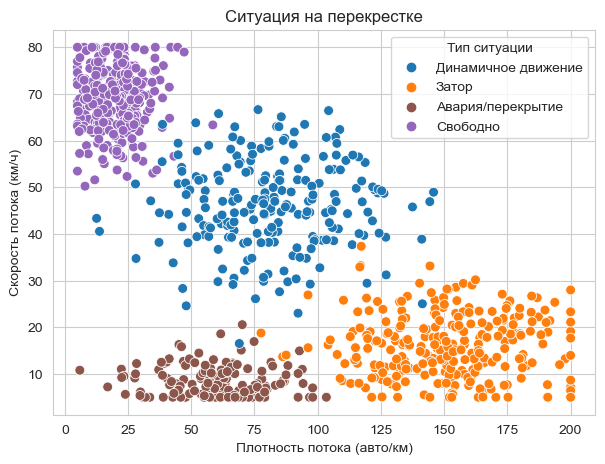

In [42]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='density', y='speed', hue='traffic_type', s=50, palette=['C0', 'C1', 'C5', 'C4'])

ax.set_title('Ситуация на перекрестке')
ax.set_xlabel('Плотность потока (авто/км)')
ax.set_ylabel('Скорость потока (км/ч)')
ax.legend(title='Тип ситуации', loc='upper right')

plt.show()

Обучаем модель. И вот тут — сюрприз. Мы не кодируем таргет. Никаких `OneHotEncoder`, `LabelEncoder`, никаких цифр. Просто берём строки и передаем их в `fit()`. И KNN работает. Да, он внутри всё равно считает расстояния, но расстояния-то он считает для `X`. 

Это не магия, это работает.

In [43]:
X = df.drop(columns=['traffic_type'])
y = df['traffic_type']

knn = KNeighborsClassifier()
knn.fit(X, y)

KNeighborsClassifier()

Модель обучилась. Достаём из рукава новую точку: плотность 146, скорость 14.8. Бросаем взгляд на график — этот парень явно где-то в зоне затора. Новые данные, новая драма. Вопрос: что скажет модель? А модель скажет своё веское слово.

In [44]:
X_new_one = pd.read_csv('data/traffic_new_one.csv')
X_new_one

,density,speed
0,146.04,14.84


Картинка подтверждает: серая точка (наш новичок) упала прямо в центр оранжевого облака. Даже без KNN видно — это затор. Но мы, учёные люди, не доверяем глазам. Хотя иногда глаза говорят правду. Просто мы слишком гордые, чтобы сразу признать очевидное.

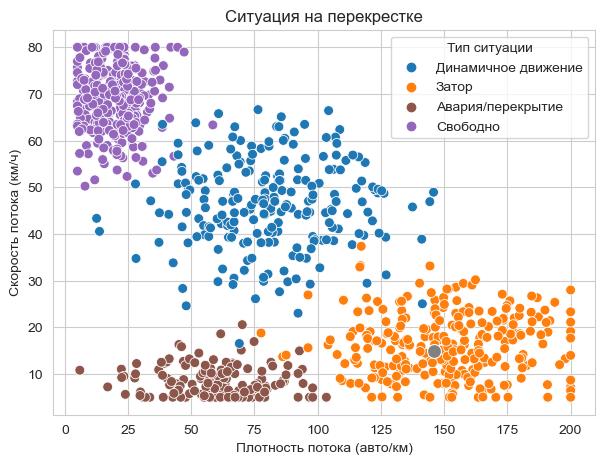

In [45]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='density', y='speed', hue='traffic_type', s=50, palette=['C0', 'C1', 'C5', 'C4'])
sns.scatterplot(data=X_new_one, x='density', y='speed', s=100, color='grey')

ax.set_title('Ситуация на перекрестке')
ax.set_xlabel('Плотность потока (авто/км)')
ax.set_ylabel('Скорость потока (км/ч)')
ax.legend(title='Тип ситуации', loc='upper right')

plt.show()

Модель сказала: «Затор». Ей можно лишь поаплодировать.

In [46]:
y_pred = knn.predict(X_new_one)
y_pred

array(['Затор'], dtype=object)

Одна точка — это мило, но несерьёзно. Давайте проверим модель на целой сотне новых наблюдений. Грузим 100 новых записей. 

In [47]:
X_new_many = pd.read_csv('data/traffic_new_many.csv')
X_new_many

,density,speed
0,146.04,14.84
1,16.55,11.17
2,21.31,67.19
3,25.61,80.00
4,27.87,70.28
...,...,...
95,38.86,61.46
96,34.41,70.15
97,82.14,7.46
98,91.81,33.42


Смотрите, как серые точки рассыпались по всему графику. Кто-то попал в зону свободного движения, кто-то — в затор, кто-то — вообще в аварию. И каждому из них модель должна дать ярлык. Сто раз подряд. ~~Без ошибок.~~ По возможности, без ошибок.

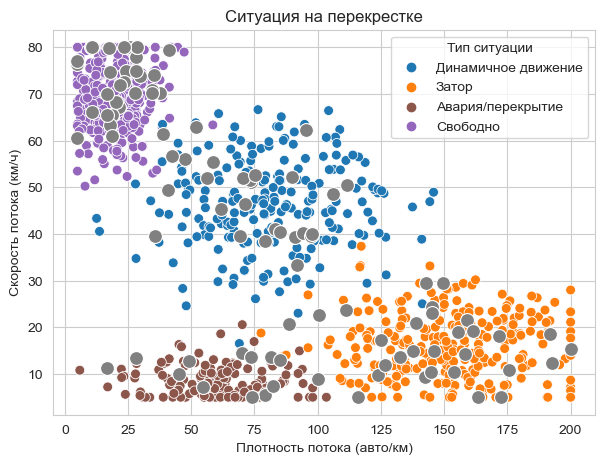

In [48]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.scatterplot(data=df, x='density', y='speed', hue='traffic_type', s=50, palette=['C0', 'C1', 'C5', 'C4'])
sns.scatterplot(data=X_new_many, x='density', y='speed', s=100, color='grey')

ax.set_title('Ситуация на перекрестке')
ax.set_xlabel('Плотность потока (авто/км)')
ax.set_ylabel('Скорость потока (км/ч)')
ax.legend(title='Тип ситуации', loc='upper right')

plt.show()

И вот — ответ. Первые 25 прогнозов. Читаем: затор, авария, свободно, свободно, свободно, затор, затор, динамичное движение, авария, динамичное движение… Смесь. Без предвзятости. KNN не думает, он смотрит на соседей и повторяет за ними. И это работает. Даже для четырёх классов. Даже для строк.

In [49]:
y_pred = knn.predict(X_new_many)
y_pred[:25]

array(['Затор', 'Авария/перекрытие', 'Свободно', 'Свободно', 'Свободно',
       'Затор', 'Затор', 'Динамичное движение', 'Авария/перекрытие',
       'Динамичное движение', 'Затор', 'Затор', 'Свободно', 'Затор',
       'Динамичное движение', 'Свободно', 'Авария/перекрытие',
       'Авария/перекрытие', 'Затор', 'Свободно', 'Свободно', 'Свободно',
       'Затор', 'Динамичное движение', 'Динамичное движение'],
      dtype=object)

## § 5. Импутация пропусков

Помните, как мы мучались с пропусками в конце первого модуля, когда занимались разведочным анализом данных? Согласитесь: обработка пропусков — это, пожалуй, самая мутная, неприятная, скользкая часть всего EDA. И CDA тоже. Потому что непонятно: то ли выбросить строки, то ли заполнить средним, то ли помедитировать на график и угадать. А хочется чего-то… ну, более научного. Чтобы с моделью. Чтобы красиво.

### 5.1. Пропуски в числовом признаке

Раньше, когда мы видели пропуски в числовом признаке, мы шли старым добрым путём: считали групповые средние и смотрели, есть ли между группами разница. Если разница была — заполняли пропуски по группам. Если нет — заливали общей средней и морщились. 

Но теперь у нас в арсенале есть регрессия. И это всё меняет. Давайте представим, что в данных о сети отелей образовались пропуски — и посмотрим на них свежим взглядом.

In [50]:
df = pd.read_csv('data/hotel_missing.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       9000 non-null   int64  
 1   weekday      9000 non-null   int64  
 2   guests       9000 non-null   int64  
 3   nights       9000 non-null   int64  
 4   stars        9000 non-null   int64  
 5   dist_center  7650 non-null   float64
 6   breakfast    9000 non-null   int64  
 7   early_book   9000 non-null   int64  
 8   cancel_days  9000 non-null   int64  
 9   price        9000 non-null   float64
dtypes: float64(2), int64(8)
memory usage: 703.3 KB


Идея — простая до гениальности. Представьте, что столбец с пропусками — это не дырявая колонка, а самый настоящий таргет. Целевая переменная. Мы возьмём ту часть датафрейма, где пропусков нет, и обучим на ней модель. А потом — отправим эту модель в production: пусть предскажет значения для строк, где пропуски есть. Модель сама додумает то, чего не хватает, опираясь на остальные признаки.

Сначала — подготовим почву. Уберём из датафрейма все строки, где есть хоть один пропуск. Да, мы сознательно выбросим часть данных — но это временная жертва. Нам нужен чистый, идеальный датасет для обучения. Как стерильная операционная. Ни одной дырки. Ни одного NaN.

In [51]:
d = df.dropna()
d

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days,price
0,3,2,1,8,3,4.58,0,73,-1,3369.41
1,4,6,2,19,4,11.75,0,26,-1,3685.47
2,1,2,5,19,4,11.71,0,162,-1,2552.05
3,3,5,4,17,3,7.52,0,61,-1,3417.73
4,3,3,2,18,4,1.72,1,262,-1,4954.84
...,...,...,...,...,...,...,...,...,...,...
8994,3,5,6,12,5,11.94,1,181,-1,6697.84
8996,1,1,2,2,4,10.43,1,175,-1,2443.73
8997,2,2,4,11,3,6.02,1,145,-1,1771.46
8998,1,0,5,12,4,2.71,1,130,-1,3064.14


Теперь — момент истины. На чистом датафрейме учим регрессию. Все признаки, кроме `'dist_center'`, идут в `X`. Сам `'dist_center'` — в `y`. Мы говорим модели: вот, смотри, вот тебе девять колонок, а вот десятая — расстояние до центра. Найди закономерность. И модель находит её.

In [52]:
X = d.drop(columns=['dist_center'])
y = d['dist_center']

model = LinearRegression()
model.fit(X, y) # Модель обучена

LinearRegression()

А теперь — идём по строчкам и чиним пропуски. Пишем функцию, которая смотрит на каждую строчку: если в `'dist_center'` пусто — она собирает из этой строки маленький датафрейм из одного наблюдения, убирает из него таргет-колонку и просит модель сделать предсказание. Модель выдаёт число — мы его округляем до двух знаков и вставляем на место пропуска. Если же значение в строке есть — возвращаем его как есть, нетронутым.

In [53]:
def imputation(row):
    if row['dist_center'] != row['dist_center']:
        X_new = row.to_frame().T
        X_new = X_new.drop(columns = ['dist_center'])
        imput = round(model.predict(X_new)[0], 2)
        return imput
    else:
        return row['dist_center']

df['dist_center'] = df.apply(imputation, axis=1)

Всё. Можно выдохнуть. 

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       9000 non-null   int64  
 1   weekday      9000 non-null   int64  
 2   guests       9000 non-null   int64  
 3   nights       9000 non-null   int64  
 4   stars        9000 non-null   int64  
 5   dist_center  9000 non-null   float64
 6   breakfast    9000 non-null   int64  
 7   early_book   9000 non-null   int64  
 8   cancel_days  9000 non-null   int64  
 9   price        9000 non-null   float64
dtypes: float64(2), int64(8)
memory usage: 703.3 KB


Пропусков в числовом признаке больше нет. Девять тысяч строк — и все с заполненным расстоянием до центра. Ни одного NaN. Мы не просто заткнули дырки средним арифметическим — мы дали модели право голоса. И модель заполнила пропуски, опираясь на логику, которую сама выучила из наших же данных. Вот это, я вам скажу, уже похоже на самое настоящее машинное обучение.

### 5.2 Пропуски в категориальном признаке

А если пропуски были в категориальном признаке — то раньше, в стародавние времена EDA и CDA, мы выкручивались принципом ярко выраженной моды. Помните? Если в какой-то группе больше восьмидесяти процентов значений приходилось на одну категорию — мы смело заливали этой категорией все пропуски в группе. Если нет — разводили руками и молились. 

Но теперь у нас есть классификация. А это уже совсем другой разговор. Давайте снова посмотрим на данные о сети отелей — только теперь с пробелами в звёздности. И представьте, что звёздность — это не просто цифра, а категория. Отель может быть трёхзвёздочным, четырёхзвёздочным, пятизвёздочным — и это не числа в привычном смысле, это классы. Пропуск в звёздности — это как если бы отель потерял табличку с фасада. А мы её сейчас найдём.

In [55]:
df = pd.read_csv('data/hotel_missing_stars.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       9000 non-null   int64  
 1   weekday      9000 non-null   int64  
 2   guests       9000 non-null   int64  
 3   nights       9000 non-null   int64  
 4   stars        7650 non-null   float64
 5   dist_center  9000 non-null   float64
 6   breakfast    9000 non-null   int64  
 7   early_book   9000 non-null   int64  
 8   cancel_days  9000 non-null   int64  
 9   price        9000 non-null   float64
dtypes: float64(3), int64(7)
memory usage: 703.3 KB


Первым делом — снова хирургический приём. Берём скальпель и отсекаем всё, что с пропусками. Нам нужен чистый датафрейм, без единой дырки, на котором мы воспитаем нашего классификатора. Он должен видеть только идеальные данные — как студент, которому не дают списывать. Пусть учится по честному.

In [56]:
d = df.dropna()
d

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days,price
0,3,2,1,8,3.0,4.58,0,73,-1,3369.41
1,4,6,2,19,4.0,11.75,0,26,-1,3685.47
2,1,2,5,19,4.0,11.71,0,162,-1,2552.05
3,3,5,4,17,3.0,7.52,0,61,-1,3417.73
4,3,3,2,18,4.0,1.72,1,262,-1,4954.84
...,...,...,...,...,...,...,...,...,...,...
8994,3,5,6,12,5.0,11.94,1,181,-1,6697.84
8996,1,1,2,2,4.0,10.43,1,175,-1,2443.73
8997,2,2,4,11,3.0,6.02,1,145,-1,1771.46
8998,1,0,5,12,4.0,2.71,1,130,-1,3064.14


Теперь — никакой линейной регрессии, она здесь бесполезна. Звёздность — это класс, категория, а не число на непрерывной шкале. Поэтому мы берём KNN — метод ближайших соседей. Он смотрит на отель и думает: ага, у этого отеля такие-то признаки, а кто на него больше всего похож среди тех, у кого звёздность известна? И голосует. 

Никаких формул, никаких предсказаний на числовой прямой. Только соседи. Только хардкор. Обучаем классификатор и молча уважаем себя за выбор правильного инструмента.

In [57]:
X = d.drop(columns=['stars'])
y = d['stars']

knn = KNeighborsClassifier()
knn.fit(X, y)

KNeighborsClassifier()

Пишем функцию для импутации. Внимание, коллеги: она отличается от той, что мы писали для числового признака. Во-первых, модель другая — классификатор, а не регрессия. Во-вторых, мы не округляем результат. Почему? Потому что округлять класс до двух знаков после запятой — это идиотизм. Представьте себе отель с 3.78 звёздами. Нет, мы предсказываем целую категорию. Три. Четыре. Пять. Всё. Функция смотрит: если звёздность отсутствует — делает из строки микро-датафрейм, выкидывает колонку со звёздами и просит классификатор сказать, к какому классу этот отель относится. Если звёздность есть — возвращает её как честный человек.

In [58]:
def imputation(row):
    if row['stars'] != row['stars']:
        X_new = row.to_frame().T
        X_new = X_new.drop(columns = ['stars'])
        imput = knn.predict(X_new)[0]
        return imput
    else:
        return row['stars']

Ну а теперь любимый метод `apply`, наш трудяга. Идём по всем строкам, ко всем 1350 отелям, которые потеряли свои звёзды, и спрашиваем KNN: эй, соседи, а этот — кто? Трёшка? Четвёрка? Пятёрка? Классификатор пожимает плечами, смотрит на соседей и выдаёт вердикт. И пропуск закрыт.

In [59]:
df['stars'] = df.apply(imputation, axis=1)
df

,season,weekday,guests,nights,stars,dist_center,breakfast,early_book,cancel_days,price
0,3,2,1,8,3.0,4.58,0,73,-1,3369.41
1,4,6,2,19,4.0,11.75,0,26,-1,3685.47
2,1,2,5,19,4.0,11.71,0,162,-1,2552.05
3,3,5,4,17,3.0,7.52,0,61,-1,3417.73
4,3,3,2,18,4.0,1.72,1,262,-1,4954.84
...,...,...,...,...,...,...,...,...,...,...
8995,4,3,1,1,4.0,6.10,0,258,-1,5244.75
8996,1,1,2,2,4.0,10.43,1,175,-1,2443.73
8997,2,2,4,11,3.0,6.02,1,145,-1,1771.46
8998,1,0,5,12,4.0,2.71,1,130,-1,3064.14


Смотрим на результат. И — о чудо! — пропусков больше нет. 9000 строк, и в каждой гордо красуется звёздность. Ни одного NaN. Мы только что заставили классификатор поработать вместо нас, и он справился. Пятнадцать процентов данных были с пропусками — и теперь они заполнены не модой, не медианой, не молитвой, а мнением модели, которая училась на наших же данных. Это, доложу я вам, приятное чувство.

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       9000 non-null   int64  
 1   weekday      9000 non-null   int64  
 2   guests       9000 non-null   int64  
 3   nights       9000 non-null   int64  
 4   stars        9000 non-null   float64
 5   dist_center  9000 non-null   float64
 6   breakfast    9000 non-null   int64  
 7   early_book   9000 non-null   int64  
 8   cancel_days  9000 non-null   int64  
 9   price        9000 non-null   float64
dtypes: float64(3), int64(7)
memory usage: 703.3 KB


Последний штрих. Смотрим на типы данных и видим: звёздность — float64. Потому что изначально в колонке были числа с плавающей точкой. Но звёздность отеля — это не дробное число, это целая категория. Отель не может быть четырёх-с-половиной-звёздочным, если это не какой-нибудь подозрительный хостел с амбициями. Поэтому переводим float в int — аккуратно, без потерь. Теперь звёздность — int32, компактно, честно и красиво.

In [61]:
df['stars'] = df['stars'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   season       9000 non-null   int64  
 1   weekday      9000 non-null   int64  
 2   guests       9000 non-null   int64  
 3   nights       9000 non-null   int64  
 4   stars        9000 non-null   int32  
 5   dist_center  9000 non-null   float64
 6   breakfast    9000 non-null   int64  
 7   early_book   9000 non-null   int64  
 8   cancel_days  9000 non-null   int64  
 9   price        9000 non-null   float64
dtypes: float64(2), int32(1), int64(7)
memory usage: 668.1 KB


Всё. Финиш. Чистенький датафрейм без пропусков. Ни в числовом признаке, ни в категориальном. Мы только что показали, что импутация пропусков — это не шаманство с бубном и не унылое заполнение средним. Это маленькая, но настоящая задача машинного обучения. В одном случае — регрессия. В другом — классификация. И обе работают. И обе — в ваших руках.

## Домашнее задание

>#### Задание 1
Прочитайте файл `vending`.

In [62]:
# Код

#### Контекст
Сеть вендинговых автоматов «Кофеин.Нет» по утрам собирает телеметрию с каждой кофе-машины. Один из ключевых датчиков — температура воды в бойлере — периодически глючит и не передаёт данные. Если не восстановить пропуски, алгоритм автоматической очистки начинает калиброваться по среднему и тупит.


Но температура сама по себе — не самоцель. Оператора интересуют два показателя качества работы автомата: насколько быстро заваривается напиток и какой объём воды тратится на цикл. Оба зависят от температуры, но не только от неё. Поэтому сначала нужно исправить данные по температуре, а затем научить модель предсказывать две целевые переменные сразу.


#### Датасет

- machine_id — идентификатор автомата (0–99) (int),

- hour — час замера (6–23) (int),

- day_type — тип дня (0 — будний, 1 — выходной) (int),

- drinks_sold — количество проданных порций за последний час (0–40) (int),

- beans_level — уровень зерен в бункере (0–100 %) (int),

- milk_level — уровень молока в баке (0–100 %) (int),

- pressure — давление в бойлере (2.0–9.0 бар) (float),

- last_clean_hours — сколько часов назад проводилась очистка (1–120) (int),

- water_temp — температура воды в бойлере (60.0–98.0 °C) (float) — есть пропуски.


#### Таргеты


- brew_time — время заваривания одной порции (15–55 сек) (float),

- water_consumption — расход воды на цикл (0.15–0.45 л) (float).


>#### Задание 2
Импутируйте пропуски в признаке `'water_temp'`.

In [63]:
# Код

>#### Задание 3
Обучите модель прогнозировать таргеты `'brew_time'` и `'water_consumption'`.

In [64]:
# Код

>#### Задание 4
Загрузите новые данные `vending_new`. Обратите внимание, что в нех тоже есть пропуски признака `'water_temp'`.

In [65]:
# Код

>#### Задание 5
Импутируйте пропуски признака `'water_temp'` в новых данных при помощи модели, обученной при выполнении задания 2.

In [66]:
# Код

>#### Задание 6
Срогнозируйте таргеты `'brew_time'` и `'water_consumption'` при помощи модели, обученной при выполнении задания 3.

In [67]:
# Код